In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, SplineTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import FunctionTransformer

In [ ]:
#Load features
df = pd.read_csv("../Modified_Pupilometri/NPImeaures_noCHerror.csv")

df["eye"] = df["eye"].map({"left": 0, "right": 1})

df["redcap_repeat_instance"] = (
    df["redcap_repeat_instance"]
    .fillna(0)
    .astype(int)
)

df = df.dropna(subset=[
    "npi", "pupil_size", "pupil_min", "ch",
    "const_velocity", "max_const_velocity",
    "dilat_velocity", "latency"
])

#Controls for z score
df_l = pd.read_csv("../Pupilometri/HC_left_NPi.csv")
df_r = pd.read_csv("../Pupilometri/HC_right_NPi.csv")
df_l = df_l.rename(columns=lambda c: c.replace("_left", ""))
df_r = df_r.rename(columns=lambda c: c.replace("_right", ""))

df_l["eye"] = "left"
df_r["eye"] = "right"

df_HC = pd.concat([df_l, df_r], ignore_index=True)


In [9]:
def z_score(x, mean, std):
    return (x - mean) / std

# use the z-scores from healthy controls

df["z_pupil_size"] = z_score(df["pupil_size"], df_HC["pupil_size"].dropna().mean(), df_HC["pupil_size"].dropna().std())
df["z_pupil_min"]  = z_score(df["pupil_min"], df_HC["pupil_min"].dropna().mean(), df_HC["pupil_min"].dropna().std())
df["z_ch"] = z_score(df["ch"], df_HC["ch"].dropna().mean(), df_HC["ch"].dropna().std())
df["z_const_velocity"] = z_score(df["const_velocity"], df_HC["const_velocity"].dropna().mean(),df_HC["const_velocity"].dropna().std())
df["z_max_const_velocity"] = z_score(df["max_const_velocity"], df_HC["max_const_velocity"].dropna().mean(), df_HC["max_const_velocity"].dropna().std())
df["z_dilat_velocity"] = z_score(df["dilat_velocity"], df_HC["dilat_velocity"].dropna().mean(), df_HC["dilat_velocity"].dropna().std())
df["z_latency"] = z_score(df["latency"], df_HC["latency"].dropna().mean(), df_HC["latency"].dropna().std())



In [ ]:
#Helper functions 
def logit_transform(y, y_min=0.0, y_max=5.0, eps=1e-6):
    """
    Logit-transform a bounded target.
    """
    y_scaled = (y - y_min) / (y_max - y_min)
    y_scaled = np.clip(y_scaled, eps, 1 - eps)
    return np.log(y_scaled / (1 - y_scaled))


def inverse_logit_transform(z, y_min=0.0, y_max=5.0):
    """
    Inverse logit-transform back to original scale.
    """
    y_scaled = 1 / (1 + np.exp(-z))
    return y_min + (y_max - y_min) * y_scaled

In [ ]:
#Define X, Y and group
TARGET = "npi"
GROUP = "record_id"
FEATURES = [
    "z_pupil_size",
    "z_pupil_min",
    "z_ch",
    "z_const_velocity",
    "z_max_const_velocity",
    "z_latency",
    "z_dilat_velocity"
]

X = df[FEATURES].copy()
y = df[TARGET].astype(float).values
y_logit = logit_transform(y, y_min=0, y_max=5)
groups = df[GROUP].values

In [ ]:
#Splines for each feature
spline_preprocessor = ColumnTransformer(
    transformers=[
        (
            "z_pupil_size",
            Pipeline([
                ("spline", SplineTransformer(
                    n_knots=5,
                    degree=3,
                    include_bias=False
                ))
            ]),
            ["z_pupil_size"]
        ),
        (
            "z_pupil_min",
            Pipeline([
                ("spline", SplineTransformer(
                    n_knots=5,
                    degree=3,
                    include_bias=False
                ))
            ]),
            ["z_pupil_min"]
        ),
         (
            "z_ch",
            Pipeline([
                ("spline", SplineTransformer(
                    n_knots=5,
                    degree=3,
                    include_bias=False
                ))
            ]),
            ["z_ch"]
        ),
        (
            "z_constriction_velocity",
            Pipeline([
                ("spline", SplineTransformer(
                    n_knots=5,
                    degree=3,
                    include_bias=False
                ))
            ]),
            ["z_const_velocity"]
        ),
                (
            "z_max_constriction_velocity",
            Pipeline([
                ("spline", SplineTransformer(
                    n_knots=5,
                    degree=3,
                    include_bias=False
                ))
            ]),
            ["z_max_const_velocity"]
        ),
        (
            "z_latency",
            Pipeline([
                ("spline", SplineTransformer(
                    n_knots=5,
                    degree=3,
                    include_bias=False
                ))
            ]),
            ["z_latency"]
        ),
        (
            "z_dilation_velocity",
            Pipeline([
                ("spline", SplineTransformer(
                    n_knots=5,
                    degree=3,
                    include_bias=False
                ))
            ]),
            ["z_dilat_velocity"]
        ),
    ],
    remainder="drop"
)
gam_pipe = Pipeline([
    ("features", spline_preprocessor),
    ("linear", LinearRegression())
])

In [ ]:
y_bins = pd.qcut(
        y_logit,
        q=5,
        labels=False,
        duplicates="drop"
    )
gkf = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

metrics = []
y_true_all = []
y_pred_all = []

#CV 

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y_bins, groups)):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_logit[train_idx], y_logit[test_idx]

    gam_pipe.fit(X_train, y_train)

    z_pred = gam_pipe.predict(X_test)

    y_pred = inverse_logit_transform(z_pred)
    y_true = inverse_logit_transform(y_test)

    metrics.append({
        "MAE": mean_absolute_error(y_true, np.round(y_pred, 1)),
        "RMSE": np.sqrt(mean_squared_error(y_true, np.round(y_pred, 1))),
        "R2": r2_score(y_true, np.round(y_pred, 1))
    })

    y_true_all.append(y_true)
    y_pred_all.append(np.round(y_pred, 1))

# Peformance
metrics_df = pd.DataFrame(metrics)
print("GAM (logit‑NPI) performance (CV mean):")
print(metrics_df.mean())

GAM (logit‑NPI) performance (CV mean):
MAE     0.039346
RMSE    0.075741
R2      0.985981
dtype: float64


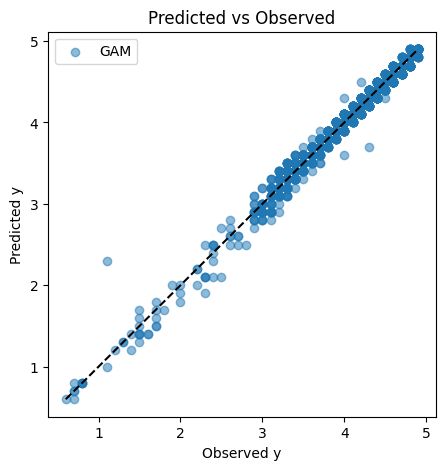

In [ ]:
# plot was from before data cleaning
y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)

plt.figure(figsize=(5, 5))

plt.scatter(y_true_all, y_pred_all, alpha=0.5, label="GAM")

lims = [
    min(y_true_all.min(), y_pred_all.min()),
    max(y_true_all.max(), y_pred_all.max())
]
plt.plot(lims, lims, "k--")

plt.xlabel("Observed y")
plt.ylabel("Predicted y")
plt.legend()
plt.title("Predicted vs Observed")
plt.show()


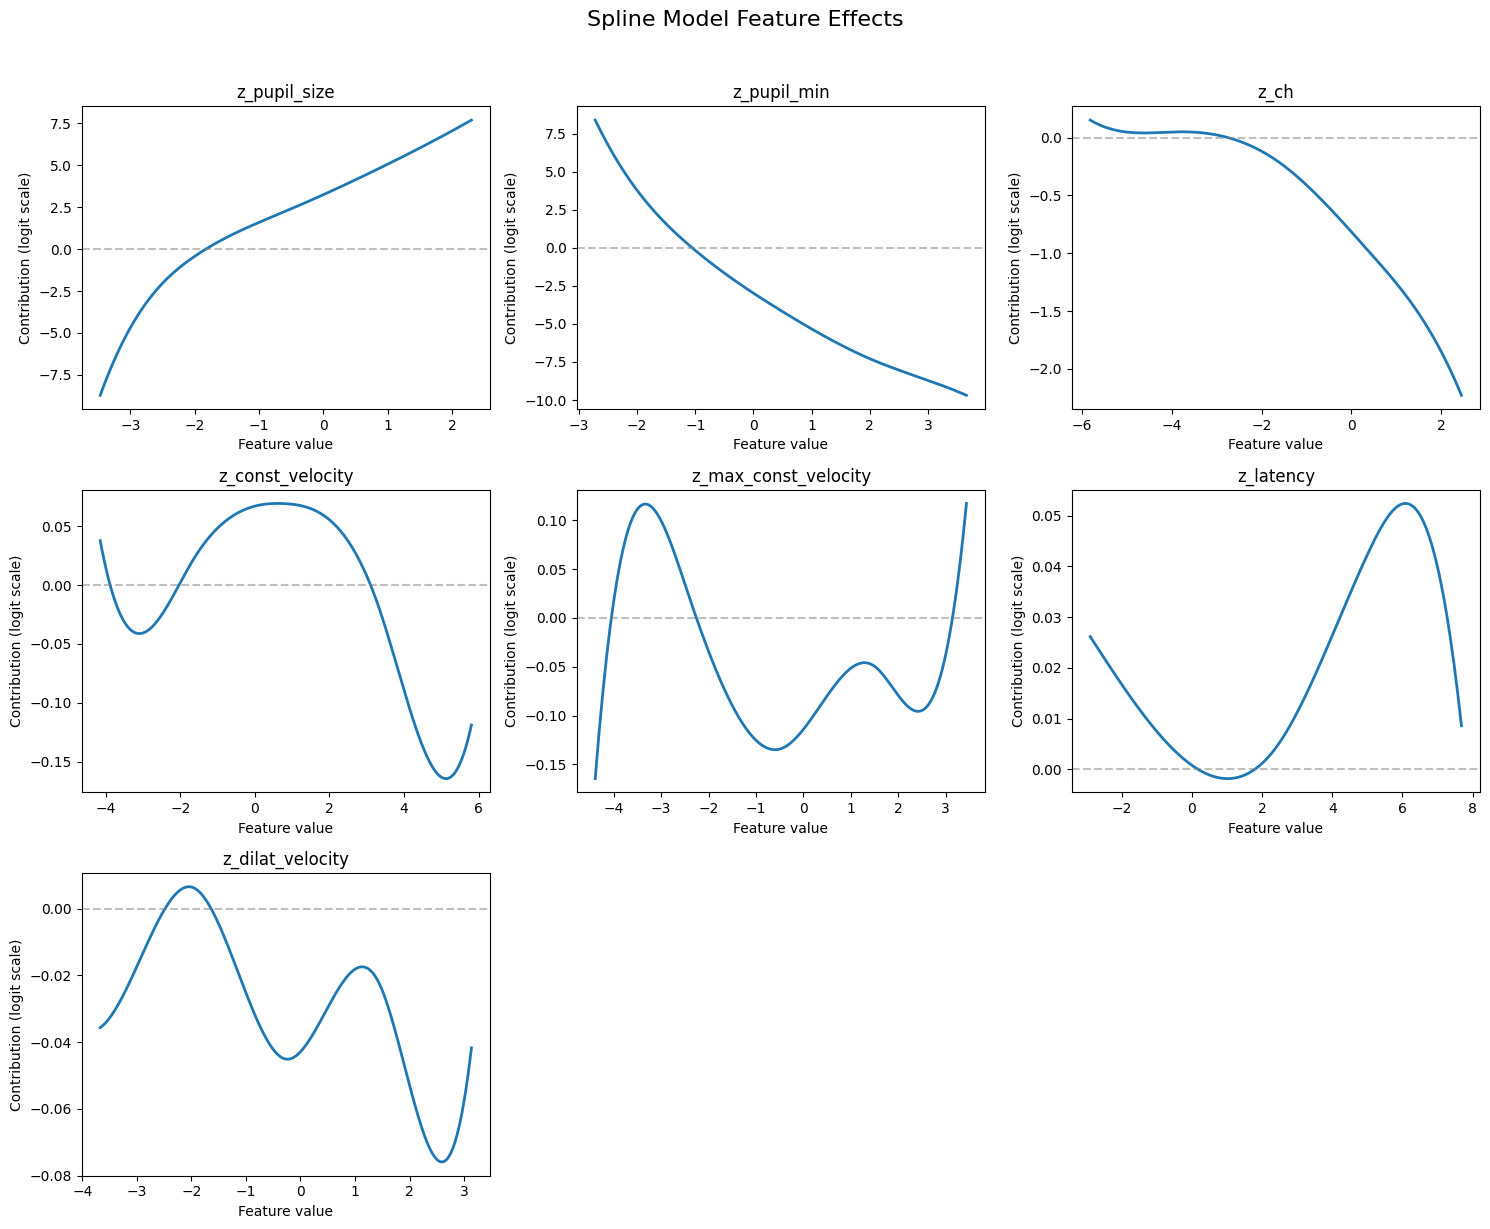

In [ ]:
# Fit full pipeline
gam_pipe.fit(X, y_logit)

model = gam_pipe.named_steps["linear"]
preprocessor = gam_pipe.named_steps["features"]

FEATURES = X.columns.tolist()

n_features = len(FEATURES)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(15, 4 * n_rows),
    sharey=False
)

axes = axes.flatten()


X_mean = X.mean().to_frame().T


X_mean_trans = preprocessor.transform(X_mean)

# Plot partial dependence

for i, feature in enumerate(FEATURES):
    ax = axes[i]

    # Grid over this feature
    grid = np.linspace(X[feature].min(), X[feature].max(), 200)

    X_grid = pd.DataFrame(
        np.repeat(X_mean.values, 200, axis=0),
        columns=FEATURES
    )
    X_grid[feature] = grid

    # Transform grid
    X_trans = preprocessor.transform(X_grid)

    # isolate effect 
    effect = (
        X_trans @ model.coef_
        - X_mean_trans @ model.coef_
    )

    ax.plot(grid, effect, linewidth=2)
    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)

    ax.set_title(feature)
    ax.set_xlabel("Feature value")
    ax.set_ylabel("Contribution (logit scale)")

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Spline Model Feature Effects", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Coeffients for splines
lin = gam_pipe.named_steps["linear"]

coefs = lin.coef_
intercept = lin.intercept_
feature_names = gam_pipe.named_steps["features"].get_feature_names_out()
for name, coef in zip(feature_names, coefs):
    print(f"{name}: {coef}")

z_pupil_size__z_pupil_size_sp_0: -41.536604287776946
z_pupil_size__z_pupil_size_sp_1: -16.51866923214115
z_pupil_size__z_pupil_size_sp_2: -10.96874956163571
z_pupil_size__z_pupil_size_sp_3: -8.850102887173222
z_pupil_size__z_pupil_size_sp_4: -6.290478846393622
z_pupil_size__z_pupil_size_sp_5: -3.448178434313188
z_pupil_min__z_pupil_min_sp_0: 38.19831834830087
z_pupil_min__z_pupil_min_sp_1: 19.441776071052434
z_pupil_min__z_pupil_min_sp_2: 12.899556954651516
z_pupil_min__z_pupil_min_sp_3: 8.877617896491738
z_pupil_min__z_pupil_min_sp_4: 5.380624081845732
z_pupil_min__z_pupil_min_sp_5: 3.7475360021581388
z_ch__z_ch_sp_0: 5.947569862660114
z_ch__z_ch_sp_1: 4.81749426252717
z_ch__z_ch_sp_2: 4.9928748181513924
z_ch__z_ch_sp_3: 4.813052184676893
z_ch__z_ch_sp_4: 3.897075277496622
z_ch__z_ch_sp_5: 3.009101673621542
z_constriction_velocity__z_const_velocity_sp_0: 0.13538701352477678
z_constriction_velocity__z_const_velocity_sp_1: -0.9452019331929752
z_constriction_velocity__z_const_velocity_sp

In [ ]:
#Fitted Gam function
terms = []
for name, coef in zip(feature_names, coefs):
    terms.append(f"{coef:.4f} * {name}")

formula = " +\n".join(terms)

print(f"z = {intercept:.4f} +\n{formula}")
print("\ny = inverse_logit(z)")

z = -1.6521 +
-41.5366 * z_pupil_size__z_pupil_size_sp_0 +
-16.5187 * z_pupil_size__z_pupil_size_sp_1 +
-10.9687 * z_pupil_size__z_pupil_size_sp_2 +
-8.8501 * z_pupil_size__z_pupil_size_sp_3 +
-6.2905 * z_pupil_size__z_pupil_size_sp_4 +
-3.4482 * z_pupil_size__z_pupil_size_sp_5 +
38.1983 * z_pupil_min__z_pupil_min_sp_0 +
19.4418 * z_pupil_min__z_pupil_min_sp_1 +
12.8996 * z_pupil_min__z_pupil_min_sp_2 +
8.8776 * z_pupil_min__z_pupil_min_sp_3 +
5.3806 * z_pupil_min__z_pupil_min_sp_4 +
3.7475 * z_pupil_min__z_pupil_min_sp_5 +
5.9476 * z_ch__z_ch_sp_0 +
4.8175 * z_ch__z_ch_sp_1 +
4.9929 * z_ch__z_ch_sp_2 +
4.8131 * z_ch__z_ch_sp_3 +
3.8971 * z_ch__z_ch_sp_4 +
3.0091 * z_ch__z_ch_sp_5 +
0.1354 * z_constriction_velocity__z_const_velocity_sp_0 +
-0.9452 * z_constriction_velocity__z_const_velocity_sp_1 +
-0.7043 * z_constriction_velocity__z_const_velocity_sp_2 +
-0.6857 * z_constriction_velocity__z_const_velocity_sp_3 +
-0.7142 * z_constriction_velocity__z_const_velocity_sp_4 +
-1.1436 * z_co